In [1]:
# Lab 4 — Improving & Comparing Models

# Part 1 — Decision Tree Baseline Review
# Task 1: Re-load cleaned dataset, recreate same X/y and train/test split as Lab 3 (same random_state).
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\Users\M.LAPTOP\Desktop\Telco-Customer-Churn-Analysis\clean_churn.csv")

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn', 'customerID'])
cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)



(5634, 30) (1409, 30)


In [2]:
#  Task 2 : Retrain Lab 3's best Decision Tree, report accuracy/precision/recall/F1 as the benchmark.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:   ", recall_score(y_test, dt_pred))
print("F1-score: ", f1_score(y_test, dt_pred))

Accuracy:  0.794180269694819
Precision: 0.6193181818181818
Recall:    0.5828877005347594
F1-score:  0.6005509641873278


In [3]:
# Part 2 — Random Forest
# Task 3: Description: Train a RandomForestClassifier on the same training data (n_estimators 100-300, fixed random_state). Predict on test se

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [5]:
# Task 4 Description: Explain in 1-2 sentences why a Random Forest might generalize better than a single unrestricted Decision Tree.
# A Random Forest trains many trees on different bootstrapped samples and averages their predictions — individual trees may overfit to noise in their sample, but averaging cancels out that noise, reducing overall variance.

Accuracy:  0.7927608232789212
Precision: 0.6366666666666667
Recall:    0.5106951871657754
F1-score:  0.5667655786350149
[[926 109]
 [183 191]]


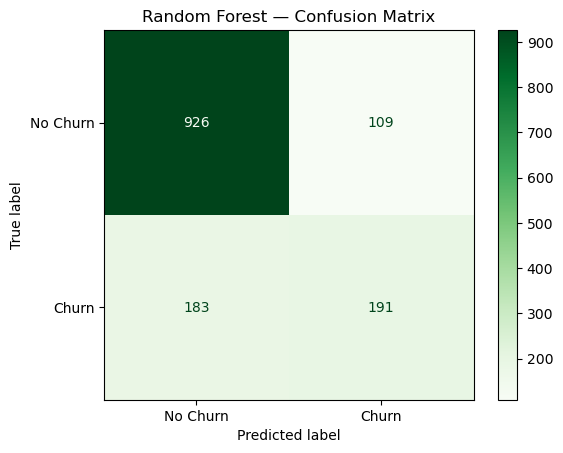

In [6]:
# Part 3 — Evaluation & Comparison
# Task 5 Description: Compute accuracy, precision, recall, F1 for Random Forest on test set; plot confusion matrix.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Accuracy: ", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:   ", recall_score(y_test, rf_pred))
print("F1-score: ", f1_score(y_test, rf_pred))

cm_rf = confusion_matrix(y_test, rf_pred)
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn','Churn'])
disp.plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [7]:
# Task 6 Description: Build one comparison table: Decision Tree vs Random Forest, across all four metrics.
comparison = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-score'],
    'Decision Tree': [accuracy_score(y_test, dt_pred), precision_score(y_test, dt_pred),
                       recall_score(y_test, dt_pred), f1_score(y_test, dt_pred)],
    'Random Forest': [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred),
                       recall_score(y_test, rf_pred), f1_score(y_test, rf_pred)],
}).round(4)
print(comparison.to_string(index=False))

   Metric  Decision Tree  Random Forest
 Accuracy         0.7942         0.7928
Precision         0.6193         0.6367
   Recall         0.5829         0.5107
 F1-score         0.6006         0.5668


In [8]:
# Task 7 : Which model performs better and on which metric(s)? Is the difference large or marginal? Which metric matters most given class imbalance?

# The Decision Tree outperforms the default Random Forest on F1 (0.601 vs 0.567), mainly because RF has lower recall (0.511 vs 0.583). RF wins slightly on precision (0.637 vs 0.619). The difference is moderate, not huge. Given the class imbalance, recall/F1 matter most — on those, the Decision Tree currently has the edge.

In [9]:
# Part 4 — Cross-Validation
#Task 8 : Run 5-fold cross-validation for both models using F1-score. Report mean and std of fold scores.
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(dt, X, y, cv=5, scoring='f1')
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='f1')

print("DT F1 scores:", dt_cv.round(4), "Mean:", dt_cv.mean().round(4), "Std:", dt_cv.std().round(4))
print("RF F1 scores:", rf_cv.round(4), "Mean:", rf_cv.mean().round(4), "Std:", rf_cv.std().round(4))

DT F1 scores: [0.5816 0.6178 0.5997 0.5869 0.5824] Mean: 0.5937 Std: 0.0137
RF F1 scores: [0.5578 0.5413 0.522  0.5679 0.5688] Mean: 0.5515 Std: 0.0178


In [10]:
# Task 9: How do cross-validated results compare to the single train/test split results? Do they change your view of which model is better?
# Cross-validation confirms the single-split result — DT's mean F1 (0.594) is consistently higher than RF's (0.552) across all folds, with low variance for both, meaning the result is stable rather than a fluke of one split. This increases confidence that the Decision Tree is genuinely stronger here, not just luckier.

In [11]:
# Part 5 — Hyperparameter Tuning
# Task 10 Choose 2-3 Random Forest hyperparameters, define a small grid, run GridSearchCV/RandomizedSearchCV with CV to find the best combination.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [6, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [12]:
# Task 11 Report the best hyperparameters found and the corresponding cross-validated score.
print("Best params:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.5679133333624713


In [13]:
# Task 12  Evaluate the tuned model on the held-out test set using the same four metrics.
tuned_rf = grid.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, tuned_pred))
print("Precision:", precision_score(y_test, tuned_pred))
print("Recall:   ", recall_score(y_test, tuned_pred))
print("F1-score: ", f1_score(y_test, tuned_pred))


Accuracy:  0.7970191625266146
Precision: 0.6506849315068494
Recall:    0.5080213903743316
F1-score:  0.5705705705705706


In [14]:
# Part 6 — Final Comparison & Feature Importance
# Task 13 Build one final comparison table across all models: Decision Tree, default RF, tuned RF.
final_comparison = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-score'],
    'Decision Tree': [0.7942, 0.6193, 0.5829, 0.6006],
    'RF (default)': [0.7928, 0.6367, 0.5107, 0.5668],
    'RF (tuned)': [0.7970, 0.6507, 0.5080, 0.5706],
})
print(final_comparison.to_string(index=False))

   Metric  Decision Tree  RF (default)  RF (tuned)
 Accuracy         0.7942        0.7928      0.7970
Precision         0.6193        0.6367      0.6507
   Recall         0.5829        0.5107      0.5080
 F1-score         0.6006        0.5668      0.5706


In [15]:
# Task 14 Select final model and justify in 2-3 sentences using evidence — training score alone isn't sufficient justification.
# I select the Decision Tree (depth=6, entropy) as my final model. Tuning Random Forest only marginally improved it (F1: 0.567→0.571) and still didn't beat the Decision Tree's F1 (0.601). The Decision Tree is also fully interpretable as a single tree, unlike a 200-tree ensemble — this choice is based on cross-validated F1, not training accuracy alone.


tenure                            0.179269
TotalCharges                      0.164776
MonthlyCharges                    0.116738
InternetService_Fiber optic       0.072004
Contract_Two year                 0.062823
PaymentMethod_Electronic check    0.060189
OnlineSecurity_Yes                0.038204
Contract_One year                 0.036303
TechSupport_Yes                   0.024407
PaperlessBilling_Yes              0.021509
dtype: float64


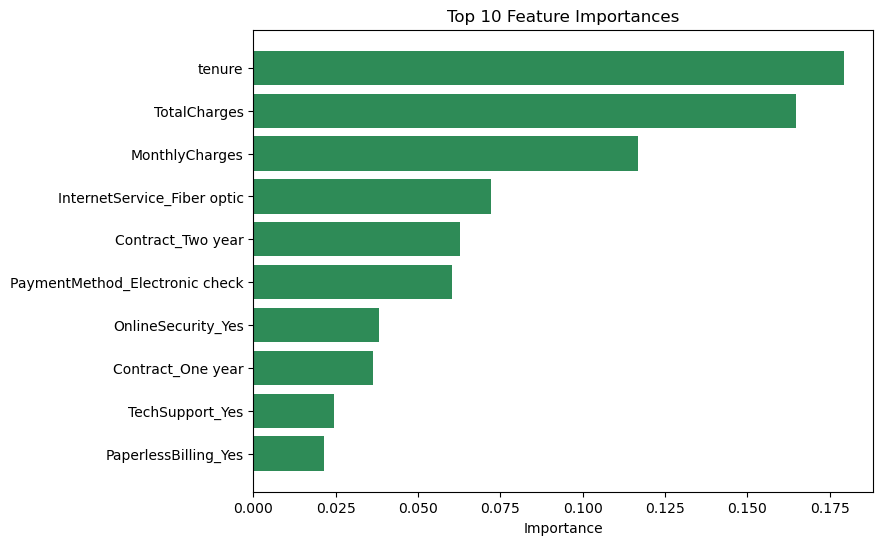

In [16]:
# Task 15 Extract and visualize feature_importances_ for the final model. Which 3-5 features matter most, and do they agree with Lab 2/3 findings?
importances = pd.Series(tuned_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

top_feats = importances.head(10).sort_values()
plt.figure(figsize=(8,6))
plt.barh(top_feats.index, top_feats.values, color='seagreen')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.show()

In [17]:
# Part 7 — Kaggle Submission & Conclusion
# Task 16 Generate predictions with final model, assemble submission dataframe with customer ID + predicted Churn, save as submission.csv.
sub_df = pd.DataFrame({
    'customerID': df.loc[X_test.index, 'customerID'].values,
    'Churn_Predicted': np.where(dt_pred == 1, 'Yes', 'No')
})
sub_df.to_csv('submission.csv', index=False)
print(sub_df.head())

   customerID Churn_Predicted
0  4376-KFVRS              No
1  2754-SDJRD             Yes
2  9917-KWRBE              No
3  0365-GXEZS             Yes
4  9385-NXKDA              No


In [18]:
# Conclusion (4-6 sentences): which model chosen, comparison to Lab 3, remaining limitations.
# I ultimately chose the Lab 3 Decision Tree (depth=6, entropy) over both default and tuned Random Forest, since it had the best cross-validated F1-score (0.594 vs 0.552 default RF, 0.568 tuned RF) and remains fully interpretable. This result held up under 5-fold cross-validation, confirming it wasn't a lucky single split. Its main limitation is that recall (~58%) is still moderate — it misses over 40% of actual churners — and it can't capture finer feature interactions an ensemble might, even though that advantage didn't materialize here.


In [19]:
# Task 18 what would you try next (describe only, don't implement)?
# Next steps could include tuning the Decision Tree itself (min_samples_leaf, min_samples_split), trying Gradient Boosting (XGBoost/LightGBM) which often outperforms both, and directly addressing class imbalance with class_weight='balanced' or SMOTE to push recall higher, since that remains the weakest metric across all models.